# Differential abundance analysis with MILO

In [ ]:
# eval "$(conda shell.bash hook)"
# conda init
# conda activate /work/islet_cartography_scrna/scrna_cartography_milo
# python -m ipykernel install --user --name scrna_cartography_milo --display-name "milo"

# https://github.com/scverse/pertpy-tutorials/blob/86069936d9d811e23558ddefb462ed78ba3eaaa9/milo.ipynb

In [1]:
# Path and system utilities
import os                    # Operating system interface
import sys                   # System-specific parameters and functions
import glob                  # File pattern matching
from pathlib import Path     # Object-oriented filesystem paths
from pyhere import here      # Reproducible project paths

# Single-cell data handling
import anndata as ad            # Core data structure for single-cell data
import scanpy as sc

# milo
import pertpy as pt
import mudata as md

# Parallel processing
from joblib import Parallel, delayed, parallel_backend

# dataframes
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt 

# Custom modules and functions
sys.path.append(str(here('scripts/misc')))  # Add custom script path to system
import diff_genes as dg
import misc as mi

/work/islet_cartography_scrna/scrna_cartography_milo/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Create directories
mi.create_directories(dir_path = str(here('data/milo/files')))
mi.create_directories(dir_path = str(here('data/milo/plots')))
mi.create_directories(dir_path = str(here('data/milo/objects')))

/work/islet_cartography_scrna/data/milo/files Directory already exists!
/work/islet_cartography_scrna/data/milo/plots Directory already exists!
/work/islet_cartography_scrna/data/milo/objects Directory already exists!


In [3]:
# Paths
base_dir = str(here('data/milo/'))
plot_dir = os.path.join(base_dir, 'plot') 
files_dir = os.path.join(base_dir, 'files') 
objects_dir = os.path.join(base_dir, 'objects') 
anndata_dir = str(here('data/anndata/'))

In [4]:
disease_order = ["nd", "pre", "t2d"]

## Load

In [5]:
adata = ad.read_h5ad(os.path.join(anndata_dir, "AH_combined.h5ad"))

## Subset adata to contain roughly the same amount of cells per donor per cell type

(50 cells) 

In [16]:
# adata_sub = dg.sample_cell_pseudobulk(adata, 'ic_id_platform_adjusted_sample', 'manual_annotation', n_cells = 50)

In [17]:
# # Number of donors in each cell type
# print(f'**Number of donors** \n{adata_sub.obs[['ic_id_platform_adjusted_sample']].drop_duplicates().value_counts().value_counts()}')
# print(f'**Number of donors in each cell type** \n{adata_sub.obs[['manual_annotation', 'ic_id_platform_adjusted_sample']].value_counts().to_frame().reset_index()[['manual_annotation']].value_counts()}')
# df = adata_sub.obs[['manual_annotation', 'ic_id_platform_adjusted_sample', 'disease_harmonized']].value_counts().to_frame().reset_index()[['manual_annotation', 'disease_harmonized']].value_counts().to_frame().reset_index()
# print(f'**Number of disease donors in each cell type** \n{df.pivot(index=['manual_annotation'], columns='disease_harmonized', values='count')}')

**Number of donors** 
count
1    210
Name: count, dtype: int64
**Number of donors in each cell type** 
manual_annotation 
alpha                 202
beta                  157
ductal                134
delta                 132
stellate_activated    123
acinar                 83
gamma                  76
endothelial_islet      74
stellate_quiescent     55
acinar_reg_plus        43
ductal_mucin           24
myeloid                15
mast                    4
endmt_early             3
cycling                 1
epsilon                 1
Name: count, dtype: int64
**Number of disease donors in each cell type** 
disease_harmonized     nd   pre   t2d
manual_annotation                    
acinar               48.0  15.0  20.0
acinar_reg_plus      25.0   8.0  10.0
alpha               122.0  21.0  59.0
beta                 99.0  20.0  38.0
cycling               1.0   NaN   NaN
delta                85.0  20.0  27.0
ductal               80.0  14.0  40.0
ductal_mucin         12.0   3.0   9.0
endmt_ea

Subset adata_sub to only keep cell types that has donors represented in all disease groups (atleast 3 donors)

In [18]:
# df2 = df.pivot(index=['manual_annotation'], columns='disease_harmonized', values='count')
# filtered = df2[df2[['nd', 'pre', 't2d']].gt(2).all(axis=1)]
# cell_types = list(filtered.index)
# adata_sub = adata_sub[adata_sub.obs['manual_annotation'].isin(cell_types)].copy()

In [19]:
# # Number of donors in each cell type
# print(f'**Number of donors** \n{adata_sub.obs[['ic_id_platform_adjusted_sample']].drop_duplicates().value_counts().value_counts()}')
# print(f'**Number of donors in each cell type** \n{adata_sub.obs[['manual_annotation', 'ic_id_platform_adjusted_sample']].value_counts().to_frame().reset_index()[['manual_annotation']].value_counts()}')
# df = adata_sub.obs[['manual_annotation', 'ic_id_platform_adjusted_sample', 'disease_harmonized']].value_counts().to_frame().reset_index()[['manual_annotation', 'disease_harmonized']].value_counts().to_frame().reset_index()
# print(f'**Number of disease donors in each cell type** \n{df.pivot(index=['manual_annotation'], columns='disease_harmonized', values='count')}')

**Number of donors** 
count
1    210
Name: count, dtype: int64
**Number of donors in each cell type** 
manual_annotation 
alpha                 202
beta                  157
ductal                134
delta                 132
stellate_activated    123
acinar                 83
gamma                  76
endothelial_islet      74
acinar_reg_plus        43
ductal_mucin           24
myeloid                15
Name: count, dtype: int64
**Number of disease donors in each cell type** 
disease_harmonized   nd  pre  t2d
manual_annotation                
acinar               48   15   20
acinar_reg_plus      25    8   10
alpha               122   21   59
beta                 99   20   38
delta                85   20   27
ductal               80   14   40
ductal_mucin         12    3    9
endothelial_islet    52    7   15
gamma                48   10   18
myeloid               8    4    3
stellate_activated   80   11   32


## Prepare for Milo analysis

In [10]:
## Initialize object for Milo analysis
milo = pt.tl.Milo()
mdata = milo.load(adata_sub)

## Build KNN graph

In K-nearest neighbor analysis, we need to specify the number of neighbors we should find for each cell

Find ideal number of neighbors to ensure that we have more than 1 cell per sample in each neighborhod

In [21]:
D = len(adata_sub.obs['ic_id_platform_adjusted_sample'].cat.categories)         # number of donors
r = 2                          # desired average cells per donor per neighbourhood

# compute r * D - the typical number of cells we assume a donor has
target_cells = r * D
# 
# compute median donor cell count - because maybe most donors have a count lower than the target sum
median_cells = np.median(D)

# Take the minimum
k = min(target_cells, median_cells)

print(f"Recommended k ≈ {k}")

Recommended k ≈ 210.0


If donors are evenly distributed → each neighborhood will have ~1.64 cells per donor on average (546/333)
If k is too small → some neighborhoods will have too few donors → unstable DA
If k is too large → neighborhoods include many donors → stable DA but blur biology

In [22]:
# default
from sklearn_ann.kneighbors.annoy import AnnoyTransformer
sc.pp.neighbors(mdata["rna"], use_rep="X_latent_1", transformer=AnnoyTransformer(210))

## Assign cells to neighborhoods

Laymen terms: We have defined using the nighbors function which cells are closest to each other, not we need to create groups of these nearby cells.
So we have a graph that shows which cells that are most similar to each other, and instead of using every cells, we use the 10 % of cells to act as a starting point for defining the neighborhoods. (so we start by looking at these cells neighbors first). Then the neighborshoods are cleaned for those that are overlapping and avoid hvaing too many neighbors that are similar. Then it finds the center of each neighborhood and then reassigns that neighborshood to the single cell closest to the center. If multiple neighborhoods end up centered on the same cell, they are merged. This way we can hopefully avoid oversamling neighborhoods

In [23]:
# default
milo.make_nhoods(mdata["rna"], prop = 0.1, seed = 1000)

See cells that are sampled as index cells of representative neighborhoods, along with their distance of the index to the kth nearest neighbor.

In [24]:
mdata["rna"][mdata["rna"].obs["nhood_ixs_refined"] != 0].obs[["nhood_ixs_refined", "nhood_kth_distance"]]

,nhood_ixs_refined,nhood_kth_distance
ic_2_1_1_GTAACGTT_ATTCCTTG,1,1.669216
ic_2_1_1_AAGATGGCT_TCGTCATG,1,1.468287
ic_2_1_1_TGAATGCATGG_ATGAAGCA,1,1.670277
ic_2_1_1_AGGTGACAC_GGGAGGTA,1,1.790474
ic_2_1_1_TCCAGGGA_TGACCCTC,1,1.211287
...,...,...
ic_25_6_6_GTCTCCACCGGG,1,1.609802
ic_25_6_6_GTGGGATGGCGC,1,1.627962
ic_25_6_6_GCCCCAAGAGGA,1,1.445910
ic_25_6_6_AAAAGAATCACT,1,1.784069


Plot the distributions of neighborhood sizes, we wantto check that the minimal value of k makes sense, and that the distrubtion of sizes are not too wide

Each row in the nhoods graph is a neighborhood, and a cell can be assigned to multiple neighborhoods

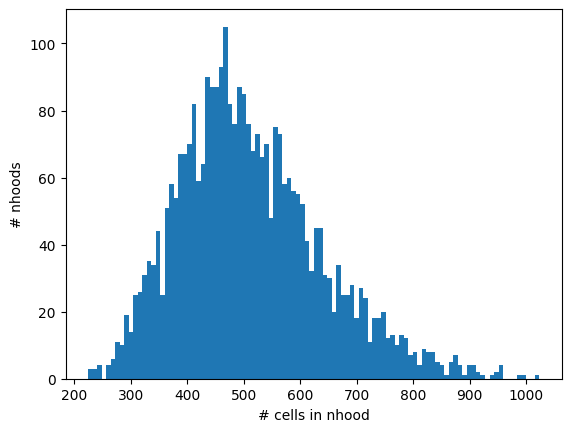

In [25]:
# Get sum per row
nhood_size = np.array(mdata["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins=100)
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods");

### Count cells in neighbourhoods

Count how many cells for each sample there are in each neighborhood, so we can use it later to account for variations in cell numbers between replicates of the same condition when we test for differential abundance

In [26]:
mdata = milo.count_nhoods(mdata, sample_col="ic_id_platform_adjusted_sample")

### Save mudata object

In [35]:
mdata.write(os.path.join(objects_dir,"mdata.h5mu"))

In [36]:
mdata = md.read(os.path.join(objects_dir,"mdata.h5mu"))

## Testing differential abundance across diabetes status

In [41]:
# Add total number of cells in each disease 
mdata["rna"].obs["total_cell_count"] = (
    mdata["rna"].obs.groupby("disease_harmonized")["disease_harmonized"]
    .transform("count")
)

milo.da_nhoods(mdata, design="~disease_harmonized", model_contrasts="disease_harmonizedt2d-disease_harmonizednd", solver="pydeseq2")

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
/work/islet_cartography_scrna/scrna_cartography_milo/lib/python3.13/site-packages/pydeseq2/dds.py:539: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(
Fitting dispersions...
... done in 0.85 seconds.

Fitting MAP dispersions...
... done in 0.98 seconds.

Fitting dispersions...
... done in 0.80 seconds.

Fitting MAP dispersions...
... done in 0.82 seconds.

Fitting dispersions...
... done in 0.69 seconds.

Fitting MAP dispersions...
... done in 1.03 seconds.

Fitting dispersions...
... done in 0.74 seconds.

Fitting MAP dispersions...
... done in 0.71 seconds.

Fitting dispersions...
... done in 0.70 seconds.

Fitting MAP dispersions...
... done in 0.65 seconds.

Fitting dispersions...
... done in 0.79 seconds.

Fitting MAP dispersions...
... done in 0.69 seconds.

Fitting dispersions...
... done in 0.85 seconds.

Fitting MAP dispersions...
... done in 0.66 seconds.

Fit

Log2 fold change & Wald test p-value: disease_harmonized t2d vs nd
        baseMean  log2FoldChange     lfcSE      stat        pvalue  \
0       0.348734        1.228795  0.524023  2.344924  1.903096e-02   
1       0.507679        1.366599  0.595226  2.295934  2.167966e-02   
2       0.339141        1.040965  0.610715  1.704501  8.828754e-02   
3     103.530122        1.402093  0.779373  1.799001  7.201858e-02   
4     213.722227        3.909587  0.560003  6.981367  2.923224e-12   
...          ...             ...       ...       ...           ...   
3127    1.321364        2.311330  0.442765  5.220214  1.787168e-07   
3128    0.724304        1.203031  0.363635  3.308344  9.384949e-04   
3129    5.615564        1.180558  0.500873  2.357002  1.842314e-02   
3130    0.913391        1.468657  0.437775  3.354820  7.941656e-04   
3131    0.514600        0.676891  0.348389  1.942916  5.202625e-02   

              padj  
0     5.075064e-02  
1     5.620919e-02  
2     1.581893e-01  
3     1.

... done in 0.73 seconds.



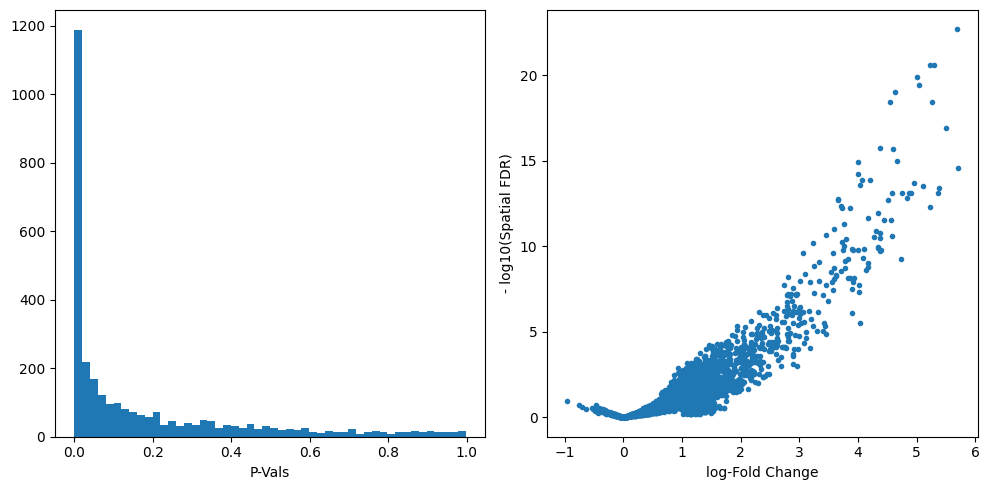

In [13]:
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10, 5]
plt.subplot(1, 2, 1)
plt.hist(mdata["milo"].var.PValue, bins=50)
plt.xlabel("P-Vals")
plt.subplot(1, 2, 2)
plt.plot(mdata["milo"].var.logFC, -np.log10(mdata["milo"].var.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

Visualize on embedding

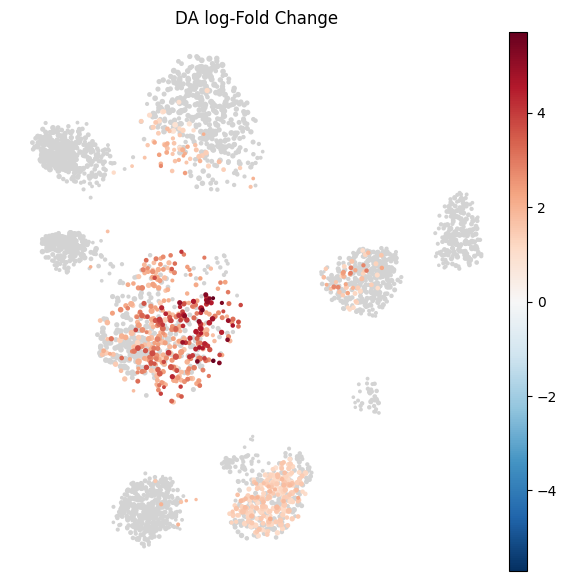

In [30]:
milo.build_nhood_graph(mdata)
plt.rcParams["figure.figsize"] = [7, 7]
milo.plot_nhood_graph(
    mdata,
    alpha=0.01,  # SpatialFDR level (1%)
    min_size=0.1,  # Size of smallest dot
)

By cell type

In [15]:
milo.annotate_nhoods(mdata, anno_col="manual_annotation")

Text(0.5, 0, 'celltype fraction')

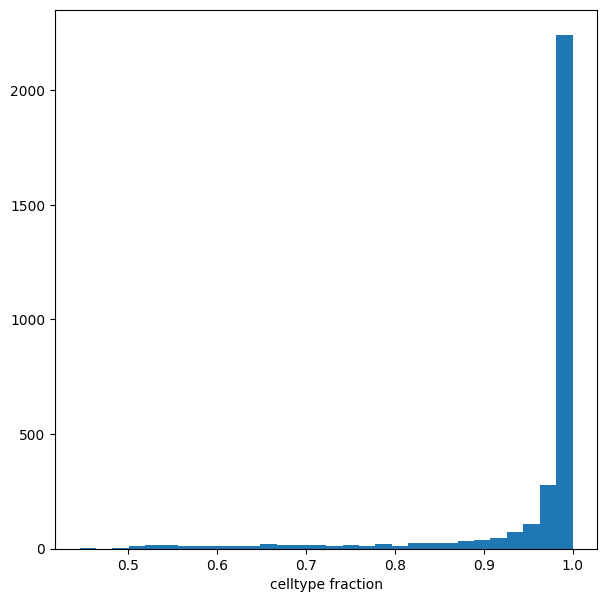

In [16]:
plt.hist(mdata["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In [18]:
mdata["milo"].var["nhood_annotation"] = mdata["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata["milo"].var.loc[mdata["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

ValueError: new categories must not include old categories: {'Mixed'}

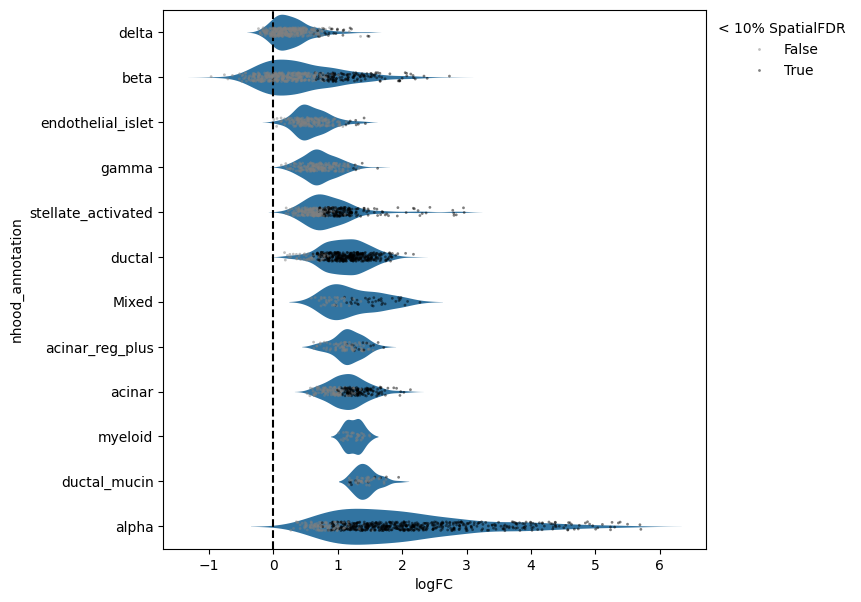

In [19]:
milo.plot_da_beeswarm(mdata, alpha=0.1)

In [22]:
mdata["milo"].obs["disease_harmonized"] = (
    mdata["milo"].obs["disease_harmonized"].astype("category").cat.reorder_categories(disease_order)
)

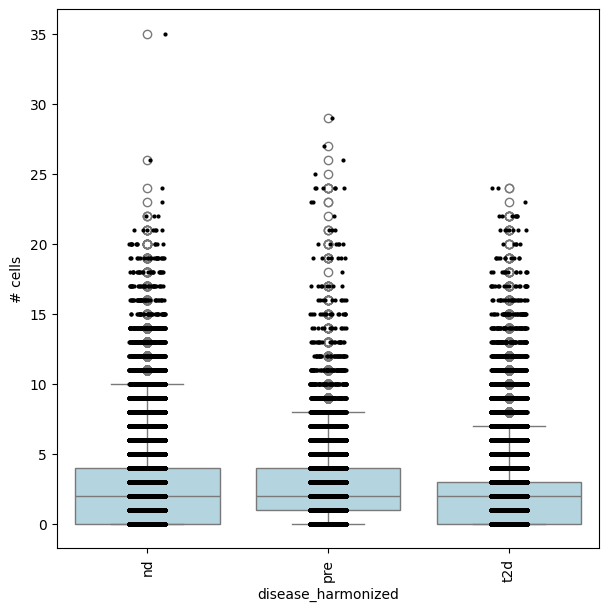

In [27]:
pl_nhoods = mdata["milo"].var_names[
    (mdata["milo"].var["SpatialFDR"] < 0.1) & (mdata["milo"].var["logFC"] > 1) & (mdata["milo"].var["nhood_annotation"] == "alpha")
]
milo.plot_nhood_counts_by_cond(mdata, test_var="disease_harmonized", subset_nhoods=pl_nhoods, log_counts=False)

IndexError: index 10 is out of bounds for axis 0 with size 10

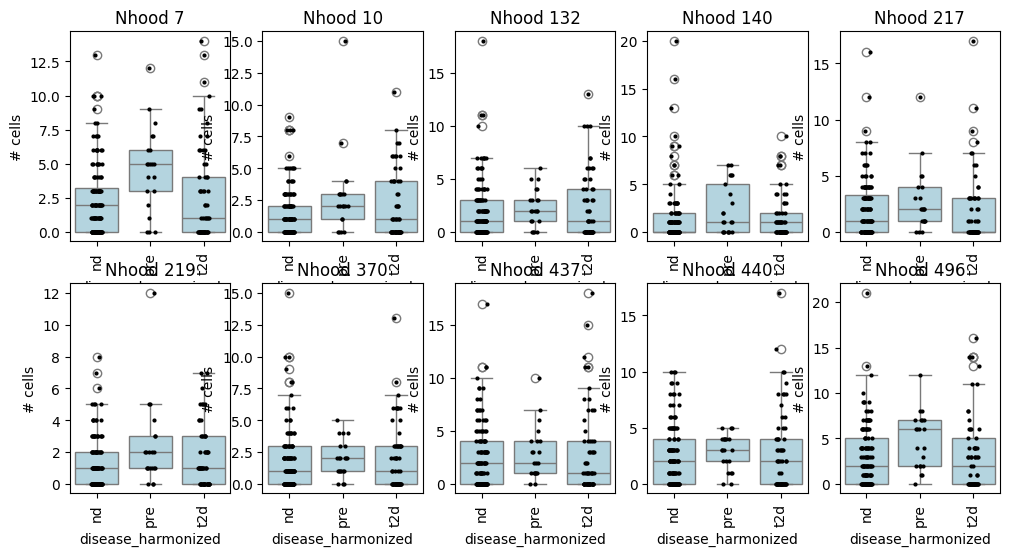

In [60]:
import matplotlib
with matplotlib.rc_context({"figure.figsize": [12, 6]}):
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    axes = axes.flatten()

    for i, nh in enumerate(pl_nhoods):
        milo.plot_nhood_counts_by_cond(
            mdata, test_var="disease_harmonized", subset_nhoods=[nh], log_counts=False, ax=axes[i], show=False
        )
        axes[i].set_title(f"Nhood {nh}")

    plt.tight_layout()

In [42]:
mdata.write(os.path.join(objects_dir,"mdata_pydeseq2.h5mu"))

In [4]:
mdata =  md.read(os.path.join(objects_dir,"mdata_pydeseq2.h5mu"))

In [85]:
# Set order of disease I want to test
from pydeseq2.default_inference import DefaultInference
inference = DefaultInference(n_cpus=60)

# Add total number of cells in each disease 
mdata["rna"].obs["total_cell_count"] = (
    mdata["rna"].obs.groupby("disease_harmonized")["disease_harmonized"]
    .transform("count")
)

disease_order = ["nd", "pre", "t2d"]

# Set the order of categories to this in my adata object
mdata["rna"].obs["disease_harmonized"] = (
    mdata["rna"].obs["disease_harmonized"]
    .astype("category")
    .cat.reorder_categories(disease_order, ordered=True)
)

# Make a column that sets disease as codes (numbers)
mdata["rna"].obs["disease_harmonized_continuous"] = (
    mdata["rna"].obs["disease_harmonized"].cat.codes
)

# Perform differential abundance testing on neighbourhoods using QLF test
milo.da_nhoods(
    mdata,
    design="~ total_cell_count+disease_harmonized_continuous",
    solver="pydeseq2",
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
/work/islet_cartography_scrna/scrna_cartography_milo/lib/python3.13/site-packages/pydeseq2/dds.py:539: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(
Fitting dispersions...
... done in 1.16 seconds.

Fitting MAP dispersions...
... done in 1.13 seconds.

Fitting dispersions...
... done in 1.15 seconds.

Fitting MAP dispersions...
... done in 1.33 seconds.

Fitting dispersions...
... done in 0.88 seconds.

Fitting MAP dispersions...
... done in 0.99 seconds.

/work/islet_cartography_scrna/scrna_cartography_milo/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Fitting dispersions...
... done in 0.98 seconds.

Fitting MAP dispersions...
... done in 1.12 seconds.

Fitting dispersions...
..

Log2 fold change & Wald test p-value: disease_harmonized_continuous 2 vs 0
       baseMean  log2FoldChange     lfcSE      stat        pvalue  \
0      9.335371        5.766980  1.146526  5.029959  4.905836e-07   
1      4.276865        2.877760  0.892216  3.225409  1.257927e-03   
2     17.999096        4.889444  1.181484  4.138391  3.497506e-05   
3     42.938034        6.386823  1.163995  5.486984  4.088535e-08   
4     77.184031       11.017085  1.399611  7.871535  3.503170e-15   
...         ...             ...       ...       ...           ...   
5091   0.544087        4.462799  1.343472  3.321839  8.942618e-04   
5092   0.659994        7.750256  1.245733  6.221441  4.926090e-10   
5093   0.499783        4.890085  1.042514  4.690665  2.723190e-06   
5094   7.303476        5.684667  1.527535  3.721465  1.980705e-04   
5095   0.400307        3.934282  1.077910  3.649916  2.623264e-04   

              padj  
0     2.900248e-06  
1     2.154031e-03  
2     9.623808e-05  
3     3.8441

... done in 0.97 seconds.



In [86]:
mdata['milo']

AnnData object with n_obs × n_vars = 192 × 5096
    obs: 'disease_harmonized_continuous', 'total_cell_count', 'ic_id_platform_adjusted_sample'
    var: 'index_cell', 'kth_distance', 'logCPM', 'logFC', 'PValue', 'FDR', 'SpatialFDR'
    uns: 'sample_col'

In [94]:
mdata.write(os.path.join(objects_dir,"mdata_pydeseq2.h5mu"))

In [11]:
## Get IDs of enriched neighbourhoods
# men hvis det er en qlf test, kan man så bruge logfc?
pl_nhoods = mdata["milo"].var_names[
    (mdata["milo"].var["SpatialFDR"] < 0.1) & (mdata["milo"].var["logFC"] > 0)
]  ## notice how here logFCs are much smaller

## Add disease order labels to mdata['milo'].obs
milo.add_covariate_to_nhoods_var(mdata, ["disease_harmonized"])
mdata["milo"].obs["disease_harmonized"] = (
    mdata["milo"].obs["disease_harmonized"].astype("category").cat.reorder_categories(disease_order)
)

## Visualize cell counts by condition (x-axis) and individuals on all signif neighbourhoods
milo.plot_nhood_counts_by_cond(mdata, test_var="disease_harmonized", subset_nhoods=pl_nhoods, log_counts=False)

NameError: name 'disease_order' is not defined

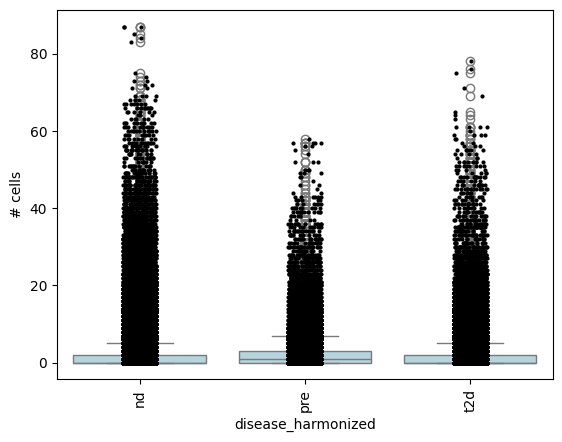

In [87]:
## Get IDs of enriched neighbourhoods
# men hvis det er en qlf test, kan man så bruge logfc?
pl_nhoods = mdata["milo"].var_names[
    (mdata["milo"].var["SpatialFDR"] < 0.1) & (mdata["milo"].var["logFC"] > 0)
]  ## notice how here logFCs are much smaller

## Add disease order labels to mdata['milo'].obs
milo.add_covariate_to_nhoods_var(mdata, ["disease_harmonized"])
mdata["milo"].obs["disease_harmonized"] = (
    mdata["milo"].obs["disease_harmonized"].astype("category").cat.reorder_categories(disease_order)
)

## Visualize cell counts by condition (x-axis) and individuals on all signif neighbourhoods
milo.plot_nhood_counts_by_cond(mdata, test_var="disease_harmonized", subset_nhoods=pl_nhoods, log_counts=False)

## Assign a cell label to each neighbourhood

To see if differential abundance is particularly evident in one cell type

In [92]:
milo.annotate_nhoods(mdata, anno_col="manual_annotation")

See in neighbourhood the fraction of celltypes

Text(0.5, 0, 'celltype fraction')

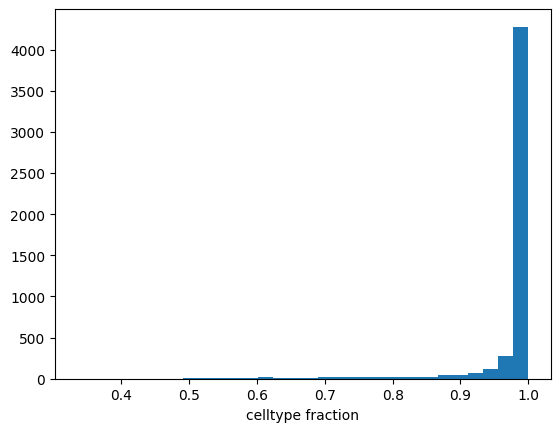

In [89]:
plt.hist(mdata["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In neighbourhoods where less than 60 % of cells are the same cell type, we call mixed

In [93]:
mdata["milo"].var["nhood_annotation"] = mdata["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata["milo"].var.loc[mdata["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

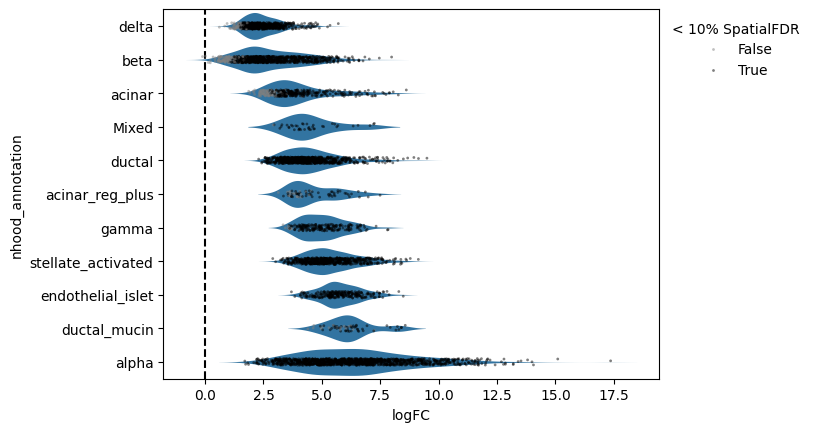

In [95]:
milo.plot_da_beeswarm(mdata, alpha=0.1)
# This shows that neighbourhoods of almost all cells are especially enriched in cells from T2D samples.

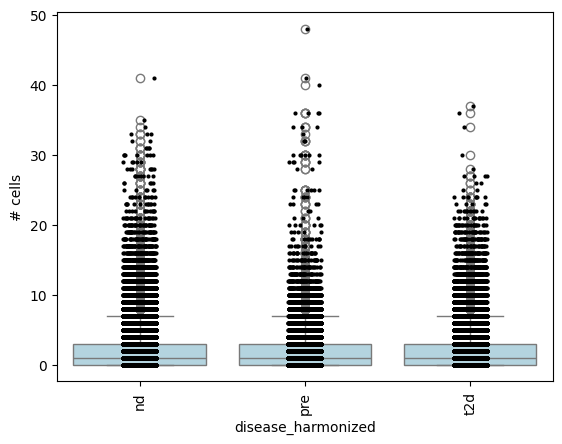

In [102]:
## Get IDs of plasmablast neighbourhood
pl_nhoods = mdata["milo"].var_names[
    (mdata["milo"].var["SpatialFDR"] < 0.1) & (mdata["milo"].var["nhood_annotation"] == "alpha")
]

## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
milo.plot_nhood_counts_by_cond(mdata, test_var="disease_harmonized", subset_nhoods=pl_nhoods, log_counts=False)

## Try pairwise comparison